# Day 4: Ensemble Methods - The Power of the Forest

## 1. From Variance to Stability: The Random Forest
A single Decision Tree is mathematically powerful but physically "brittle." Small fluctuations in detector noise can lead to wildly different branch structures (High Variance). To solve this, we move to **Ensemble Learning**.

### The Mathematical Framework:
A Random Forest is a collection of $N$ independent decision trees $\{h_1(\vec{x}), h_2(\vec{x}), \dots, h_N(\vec{x})\}$. It relies on two primary mechanisms to ensure diversity among trees:

1. **Bootstrap Aggregating (Bagging):** Each tree is trained on a random subset of 200,000 events sampled *with replacement*. This ensures no two trees see the exact same dataset.
2. **Feature Subspacing:** At every node split, the algorithm only "sees" a random subset of the 24 kinematic features (typically $\sqrt{24} \approx 5$). This forces the forest to learn from weaker kinematic correlations that a single dominant tree would ignore.

The final classification is the arithmetic mean of the probabilistic outputs:
$$\hat{y} = \frac{1}{N} \sum_{i=1}^{N} h_i(\vec{x})$$

By the **Law of Large Numbers**, as the number of trees $N$ increases, the variance of the ensemble decreases without increasing the bias, leading to a much more stable "Higgs-vs-Background" filter.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

df = pd.read_csv('training.csv').replace(-999.0, np.nan)
cols_to_drop = df.columns[df.isna().mean() > 0.70].tolist() + ['EventId', 'Weight']
df_clean = df.drop(columns=cols_to_drop)
for col in df_clean.columns:
    if df_clean[col].isna().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean['Label'] = df_clean['Label'].map({'s': 1, 'b': 0})
X = df_clean.drop(columns=['Label'])
y = df_clean['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [2]:
print("--- Training Random Forest (100 Trees) ---")

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

--- Training Random Forest (100 Trees) ---
Accuracy: 83.26%
ROC-AUC Score: 0.9007

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     32867
           1       0.78      0.71      0.74     17133

    accuracy                           0.83     50000
   macro avg       0.82      0.80      0.81     50000
weighted avg       0.83      0.83      0.83     50000



## 2. Gradient Boosting: XGBoost
While Random Forest grows trees in parallel, **XGBoost** grows them sequentially. Each new tree attempts to correct the errors made by the previous ones by minimizing a differentiable loss function using Gradient Descent. 

Because it focuses on the "hard" examples (the events where $M_H$ and $M_Z$ overlap most severely), XGBoost typically provides the highest precision possible in high-energy physics datasets.

In [3]:
from xgboost import XGBClassifier

print("--- Training XGBoost (Gradient Boosting) ---")

xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")
print(f"XGBoost ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

--- Training XGBoost (Gradient Boosting) ---


c:\Users\harsh\OneDrive\Desktop\higgs_boson\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:41:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 83.55%
XGBoost ROC-AUC: 0.9047

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88     32867
           1       0.78      0.72      0.75     17133

    accuracy                           0.84     50000
   macro avg       0.82      0.81      0.81     50000
weighted avg       0.83      0.84      0.83     50000



## 3. Comparison of Models: The ROC Curve
The Receiver Operating Characteristic (ROC) curve plots the **True Positive Rate (Recall)** against the **False Positive Rate**. A perfect model would reach the top-left corner (0,1). The area under this curve (AUC) is our primary metric for discovery potential.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
print("Re-calculating baseline probabilities for the ROC plot...")

log_reg = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

tree_clf = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_train, y_train)
y_prob_tree = tree_clf.predict_proba(X_test)[:, 1]

print("Baselines ready.")

Re-calculating baseline probabilities for the ROC plot...
Baselines ready.


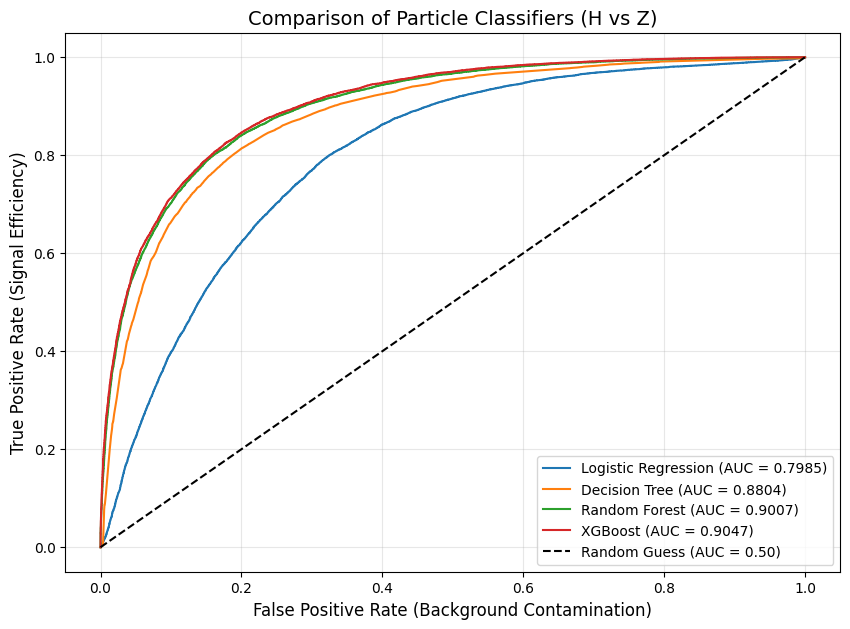

In [7]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(10, 7))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = 0.7985)')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = 0.8804)')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = 0.9007)')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = 0.9047)')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

plt.xlabel('False Positive Rate (Background Contamination)', fontsize=12)
plt.ylabel('True Positive Rate (Signal Efficiency)', fontsize=12)
plt.title('Comparison of Particle Classifiers (H vs Z)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()